# 📉 Customer Churn Prediction & Retention Strategy

### Telco Customer Churn Case Study

**Objective:**  
Predict customer churn using machine learning and translate model outputs into actionable business retention strategies.

---

## Business Context

Customer churn significantly impacts recurring revenue businesses.  
This project builds a predictive model to:

- Identify high-risk customers
- Understand key churn drivers
- Recommend targeted retention strategies

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 200)

# Load data
path = "../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Quick sanity checks
print("\nMissing values (top):")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget distribution:")
display(df["Churn"].value_counts(dropna=False))
display(df["Churn"].value_counts(normalize=True).rename("proportion"))


Missing values (top):


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


Target distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Dataset Overview

- Total customers: 7,043
- Target variable: **Churn (Yes/No)**
- Features include:
  - gender
  - Monthly charges
  - Streaming movies
  - Internet services
  - Tech Support

The dataset represents subscription-based telecom customers.

In [9]:
# TotalCharges sometimes loads as string with blanks
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("TotalCharges missing after conversion:", df["TotalCharges"].isna().sum())

# Drop rows where TotalCharges is missing (usually very few)
df = df.dropna(subset=["TotalCharges"]).copy()
print("Shape after dropping TotalCharges NaNs:", df.shape)

TotalCharges dtype: float64
TotalCharges missing after conversion: 11
Shape after dropping TotalCharges NaNs: (7032, 21)


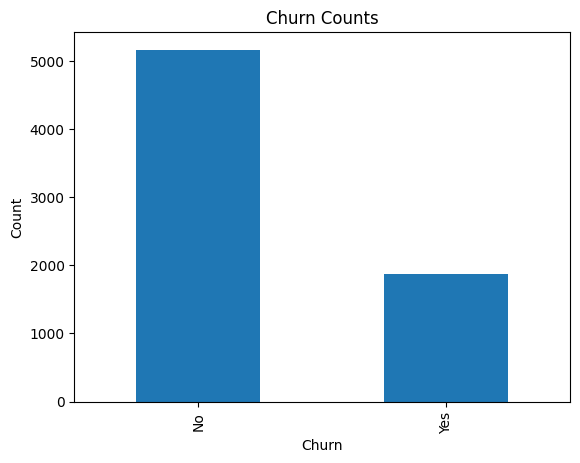

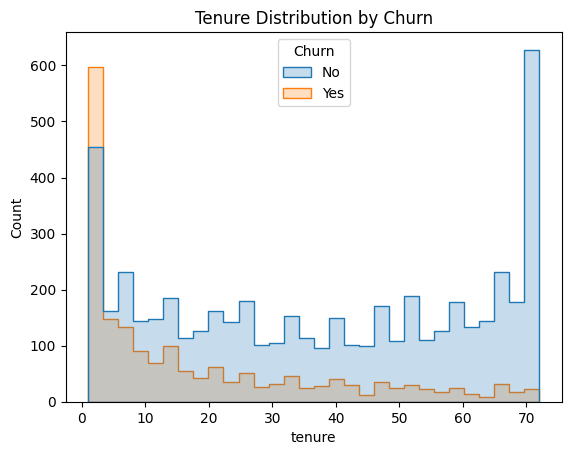

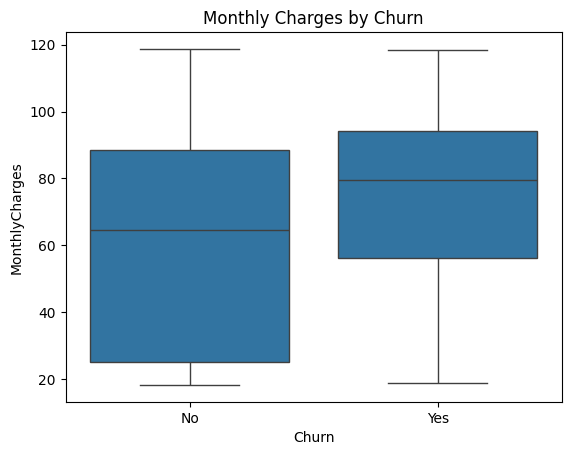

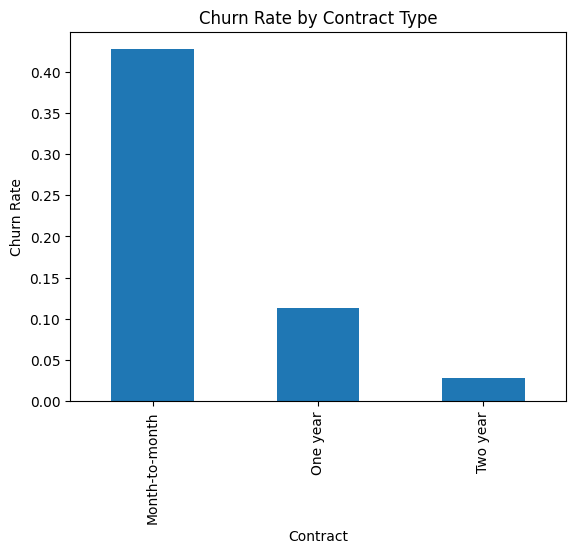

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: churn_rate, dtype: float64

In [4]:
# Churn %
plt.figure()
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Counts")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Tenure vs churn
plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=False, element="step")
plt.title("Tenure Distribution by Churn")
plt.show()

# MonthlyCharges vs churn
plt.figure()
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

# Contract vs churn rate
plt.figure()
contract_rate = (df.groupby("Contract")["Churn"]
                 .apply(lambda s: (s=="Yes").mean())
                 .sort_values(ascending=False))
contract_rate.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

display(contract_rate.rename("churn_rate"))

## 🔎 Key Exploratory Insights

1. Overall churn rate ≈ **26.5%**
2. **Month-to-month contracts** show highest churn rate (~42.7%)
3. Customers with low tenure are more likely to churn
4. Higher monthly charges correlate with increased churn probability

These findings suggest pricing structure and contract flexibility are major churn drivers.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Drop customerID (not useful)
df_model = df.drop(columns=["customerID"]).copy()

# Convert target to binary
df_model["Churn"] = df_model["Churn"].map({"Yes":1, "No":0})

# Split features & target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# Identify numeric & categorical columns
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC AUC: 0.8359290473207676


In [14]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC AUC: 0.8139989957084653


In [15]:
xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

C:\UTS\Sem_4\Churn prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:42:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.57      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.76      0.77      0.76      1407

ROC AUC: 0.8088403538833469


## 🤖 Model Performance Summary

| Model | ROC-AUC | Accuracy | Recall (Churn=Yes) |
|-------|---------|----------|--------------------|
| Logistic Regression | **0.836** | 0.80 | 0.57 |
| Random Forest | 0.814 | 0.79 | 0.49 |
| XGBoost | 0.809 | 0.77 | 0.53 |

### Interpretation

- Logistic Regression achieved the highest ROC-AUC.
- The model identifies **57% of churners**, enabling proactive intervention.
- The simplicity and interpretability of Logistic Regression make it ideal for business deployment.

In [16]:
# Get feature names after preprocessing
ohe = log_model.named_steps["preprocess"].named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(cat_cols)

all_features = list(num_cols) + list(encoded_cat_cols)

# Get coefficients
coefficients = log_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

display(feature_importance.head(15))
display(feature_importance.tail(15))

,Feature,Coefficient
3,TotalCharges,0.644014
36,Contract_Month-to-month,0.613846
16,InternetService_Fiber optic,0.590184
32,StreamingTV_Yes,0.191113
43,PaymentMethod_Electronic check,0.180671
35,StreamingMovies_Yes,0.177076
18,OnlineSecurity_No,0.164459
27,TechSupport_No,0.142949
14,MultipleLines_Yes,0.088164
0,SeniorCitizen,0.071011


,Feature,Coefficient
30,StreamingTV_No,-0.217061
9,Dependents_Yes,-0.270520
22,OnlineBackup_No internet service,-0.283724
34,StreamingMovies_No internet service,-0.283724
28,TechSupport_No internet service,-0.283724
19,OnlineSecurity_No internet service,-0.283724
17,InternetService_No,-0.283724
31,StreamingTV_No internet service,-0.283724
25,DeviceProtection_No internet service,-0.283724
12,MultipleLines_No,-0.293470


In [17]:
# Assume:
avg_monthly_revenue = df["MonthlyCharges"].mean()
total_customers = len(df)
churn_rate = df_model["Churn"].mean()

monthly_revenue_loss = total_customers * churn_rate * avg_monthly_revenue

print("Estimated Monthly Revenue at Risk: $", round(monthly_revenue_loss, 2))

Estimated Monthly Revenue at Risk: $ 121107.85


In [18]:
import joblib
joblib.dump(log_model, "../src/churn_model.joblib")
print("Saved model to ../src/churn_model.joblib")

Saved model to ../src/churn_model.joblib


## 🔎 Top Churn Drivers (Model Interpretation)

Using Logistic Regression coefficients, we identify the strongest drivers of churn.

---

### 🚨 Strongest Positive Drivers (Increase Churn Risk)

1️⃣ **TotalCharges (+0.64)**  
Higher total spend is associated with increased churn probability.  
This suggests long-term customers with accumulated costs may experience value fatigue.

2️⃣ **Contract: Month-to-Month (+0.61)**  
Customers on flexible contracts are significantly more likely to churn.  
This confirms contract structure is the strongest structural churn driver.

3️⃣ **InternetService: Fiber Optic (+0.59)**  
Fiber customers show higher churn risk, possibly due to higher pricing or competitive alternatives.

4️⃣ **Streaming Services & Add-ons (StreamingTV, StreamingMovies, TechSupport = No)**  
Customers lacking service protection/support features are more prone to churn.

5️⃣ **Electronic Check Payment Method (+0.18)**  
This payment type is associated with higher churn, possibly indicating lower engagement stability.

---

### 🛡 Strongest Negative Drivers (Reduce Churn Risk)

1️⃣ **Tenure (-1.35)**  
The most powerful protective factor.  
The longer a customer stays, the less likely they are to churn.

2️⃣ **Contract: Two-Year (-0.78)**  
Long-term contracts significantly reduce churn risk.

3️⃣ **InternetService: DSL (-0.62)**  
DSL users show lower churn compared to fiber customers.

4️⃣ **MonthlyCharges (-0.54)**  
Lower monthly charges reduce churn risk, confirming price sensitivity.

5️⃣ **Dependents: Yes (-0.27)**  
Customers with dependents are more stable and less likely to churn.

---

## 🧠 Strategic Insight

Churn is primarily driven by:

- Contract flexibility
- Early lifecycle customers
- Premium/fiber internet pricing
- Lack of service lock-in mechanisms

Retention strategies should focus on:

- Converting month-to-month users
- Improving onboarding experience
- Providing loyalty incentives to fiber customers
- Increasing customer stickiness through bundled services

## 💼 Business Recommendations

### 1️⃣ Contract Optimization Strategy
- Prioritize month-to-month customers
- Offer incentives for annual contracts

### 2️⃣ Early Lifecycle Retention Program
- Target customers within first 6 months
- Improve onboarding support

### 3️⃣ High-Charge Customer Protection
- Offer value-based bundles
- Conduct proactive customer satisfaction outreach

### 4️⃣ Risk-Based Outreach
- Use churn probability scores to prioritize retention campaigns